In [2]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from tqdm import tqdm

import pandas as pd

from scipy import stats

import pyunfold as pu

In [3]:
def T(A):
    return np.swapaxes(A, -2, -1)

In [4]:
Prop = Propagator()
density_model = ('MSIS00', ('SouthPole', 'January'))
tag = 'DomeC'

In [5]:
df_Pfast = pd.read_csv('Production Rates/P_fast_SouthPole_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_SouthPole_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

In [6]:
# The only production model being used is Heisinger
i = model_names.index('Heisinger')
prod_cut = np.arange(len(P_14C))[i:i+1]

In [7]:
Prop.Phi['prod']=P_14C[prod_cut]
C_flow_response = F.flow_14C_response(Prop)
C_response = C_flow_response @ Prop.S_mat[Prop.i_start:]

In [8]:
# SET TIME-DEPENDENT FLUX MODEL

t_bins = Prop.t_bins[Prop.i_start:]-Prop.t_bins[-1] # time in years, with 0=present
t = Prop.t[Prop.i_start:]-Prop.t_bins[-1]
t_scale = t/-t_bins[0] # time scaled from -1 to 0, with 0=present
t_bins_scale = (t_bins/-t_bins[0]).reshape((1,-1))
dt_bins_scale = np.diff(t_bins_scale,axis=-1)

N_poly = 5

f_poly = np.array([t_scale**i for i in range(N_poly)])

N_step = 100

#t_step = np.reshape(np.linspace(-1., 0., N_step+1), (-1,1))
#f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale))/dt_bins_scale
t_step = np.reshape(np.arange(-1.,2./(N_step-1),1./(N_step-1)), (-1,1))
f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)))*(N_step-1)

N_interp = 6

t_step = np.reshape(np.arange(-1.,2./(N_interp-1),1./(N_interp-1)), (-1,1))
f_interp = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,1./(N_interp-1)) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,1./(N_interp-1)))*(N_interp-1)

In [9]:
np.shape(f_step)

(100, 7283)

In [10]:
dc = 10.
gauss_centers = np.arange(t_bins[0], t_bins[-1]+dc, dc)
dw = 100.
gauss_widths = np.arange(dw, Prop.t_bins[-1]+dw, dw)
f_gauss = np.exp(-((t.reshape((1,1,-1))-gauss_centers.reshape((-1,1,1)))/gauss_widths.reshape((1,-1,1)))**2/2)/gauss_widths.reshape((1,-1,1))
#axis0 - gaussian center
#axis1 - gaussian width
#axis2 - integration time

In [11]:
np.shape(f_gauss)

(730, 98, 7283)

In [15]:
C_flow_poly = np.swapaxes(f_poly @ C_flow_response, 1,2)
C_flow_step = np.swapaxes(f_step @ C_flow_response, 1,2)
C_flow_interp = np.swapaxes(f_interp @ C_flow_response, 1,2)
C_flow_gauss = np.moveaxis([f @ C_flow_response for f in tqdm(f_gauss)], (0,2), (1,-2))

100%|█████████████████████████████████████████████████████████████████████████████████| 730/730 [01:38<00:00,  7.39it/s]


In [16]:
np.shape(C_flow_gauss)

(1, 730, 98, 2, 7283)

In [14]:
np.shape(C_flow_step)

(1, 100, 2, 7283)

In [17]:
C_poly = np.swapaxes(f_poly @ C_response, 1,2)
C_step = np.swapaxes(f_step @ C_response, 1,2)
C_interp = np.swapaxes(f_interp @ C_response, 1,2)
C_gauss = np.moveaxis([f @ C_response for f in tqdm(f_gauss)], (0,2), (1,-2))

100%|███████████████████████████████████████████████████████████████████████████████| 730/730 [00:00<00:00, 1901.70it/s]


In [18]:
df = pd.read_csv('factors_2sigma_hull.csv', header=None)
f_factors = np.array([df[1],df[0]]).T
f_weights = np.ones(len(f_factors))
f_avg = np.average(f_factors, axis=0)

In [23]:
CO_poly = np.swapaxes(f_factors @ C_poly, 1,2)
CO_avg_poly = f_avg @ C_poly
CO_avg_flow_poly = f_avg @ C_flow_poly

CO_step = np.swapaxes(f_factors @ C_step, 1,2)
CO_avg_step = f_avg @ C_step
CO_avg_flow_step = f_avg @ C_flow_step

CO_interp = np.swapaxes(f_factors @ C_interp, 1,2)
CO_avg_interp = f_avg @ C_interp
CO_avg_flow_interp = f_avg @ C_flow_interp

CO_gauss = np.moveaxis(f_factors @ C_gauss, -2,1)
CO_avg_gauss = f_avg @ C_gauss
CO_avg_flow_gauss = f_avg @ C_flow_gauss

In [25]:
rel_err = 0.02
#rel_err = 0.

In [26]:
np.shape(CO_avg_interp)

(1, 6, 10)

In [27]:
CO_samp = CO_avg_interp[0]

N = 10
amp = 0.2
s = np.random.normal(0,rel_err,(N, np.shape(CO_samp)[-1]))
f_samp = np.random.rand(np.shape(CO_samp)[-2])*amp*2+1-amp
#f_samp = np.ones(len(Prop.z_samp))
#x = CO_avg_poly[0,0]*(1+s)
x = (f_samp @ CO_samp)*(1+s)

In [28]:
#X = x[2]
#R = (f_avg @ np.swapaxes(C_response, 1,2))[0].T
R = CO_avg_step[0].T

unfold_results = [pu.iterative_unfold(
    data = X,
    data_err = X*rel_err,
    response = R,
    response_err = np.sqrt(abs(R))*0.,
    efficiencies = np.sum(R,axis=0),
    efficiencies_err = np.sum(R,axis=0)*rel_err,
    #callbacks=[pu.Logger()],
    ts_stopping = 0.0001
) for X in x]

/home/wcook/.local/lib/python3.10/site-packages/pyunfold/mix.py:64: RuntimeWarning: invalid value encountered in sqrt
  err = np.sqrt(cvm.diagonal())


In [29]:
np.shape(R)

(10, 100)

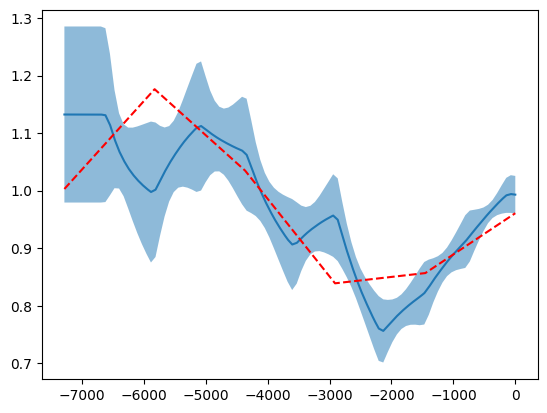

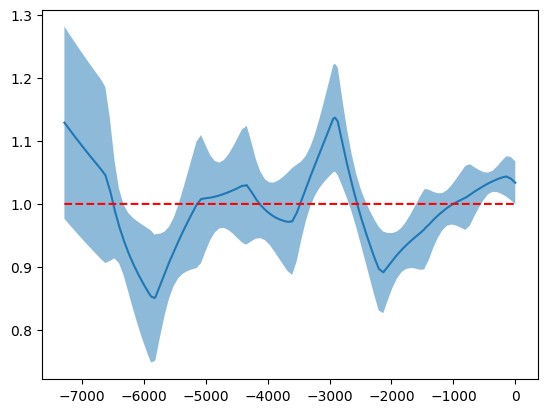

In [30]:
f_pred = f_samp @ f_interp

for u in unfold_results[:1]:
    #plt.plot(t, u['unfolded'] @ f_step)
    u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
    plt.fill_between(t, (u['unfolded']- u_err) @ f_step, (u['unfolded']+ u_err) @ f_step, alpha=0.5)
    plt.plot(t, u['unfolded'] @ f_step)
plt.plot(t, f_pred, ls='--', c='r')
#plt.ylim((0.7,1.3))
plt.show()

for u in unfold_results[:1]:
    #plt.plot(t, u['unfolded'] @ f_step)
    u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
    plt.fill_between(t, (u['unfolded']- u_err) @ f_step / f_pred, (u['unfolded']+ u_err) @ f_step / f_pred, alpha=0.5)
    plt.plot(t, u['unfolded'] @ f_step / f_pred)
plt.plot(t, f_pred/f_pred, ls='--', c='r')
#plt.ylim((0.7,1.3))
plt.show()

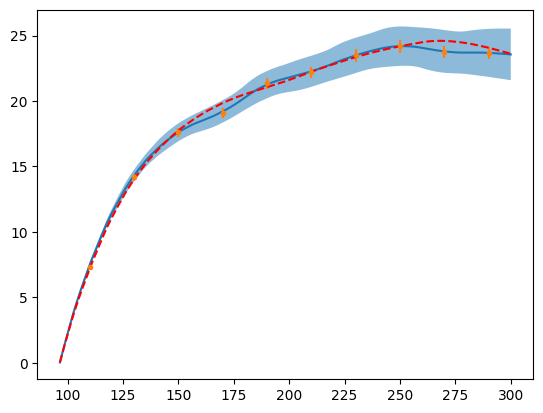

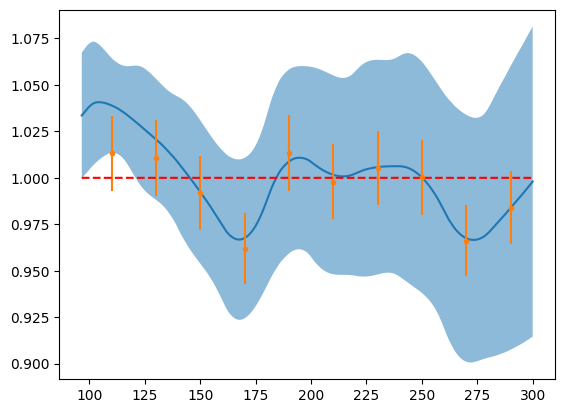

In [31]:
c_pred = f_samp @ CO_avg_flow_interp[0]
z = Prop.z[Prop.i_start:]
z_samp = Prop.z_samp

for i,u in enumerate(unfold_results[:1]):
    u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
    plt.fill_between(z, (u['unfolded']-u_err) @ CO_avg_flow_step[0], (u['unfolded']+u_err) @ CO_avg_flow_step[0], alpha=0.5)
    plt.plot(z, u['unfolded'] @ CO_avg_flow_step[0])
    plt.errorbar(z_samp, x[i], yerr=x[i] *0.02, fmt='.')
plt.plot(z, c_pred, ls='--', c='r')
#plt.ylim((0.7,1.3))
plt.show()

for i,u in enumerate(unfold_results[:1]):
    u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
    plt.fill_between(z, (u['unfolded']-u_err) @ CO_avg_flow_step[0]  / c_pred, (u['unfolded']+u_err) @ CO_avg_flow_step[0]  / c_pred, alpha=0.5)
    plt.plot(z, u['unfolded'] @ CO_avg_flow_step[0] / c_pred)
    plt.errorbar(z_samp, x[i] / np.interp(z_samp, z, c_pred), yerr=x[i] *rel_err /np.interp(z_samp, z, c_pred), fmt='.')
plt.plot(z, c_pred/c_pred, ls='--', c='r')
#plt.ylim((0.7,1.3))
plt.show()